# MNIST Dataset – Machine Learning Workflow

**Dataset:** MNIST Handwritten Digits (42,000 images × 784 pixel features)  
**ML Task Type:** Multi-class Classification (Supervised Learning)  
Each image is a 28×28 grayscale photo of a digit (0–9), flattened into 784 pixel values.

Since the CSV has no label column, we use **KMeans clustering** to assign labels (10 clusters = 10 digits), then train a supervised classifier on those labels.

## Step i: Loading the Dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, chi2, f_classif
from sklearn.cluster import MiniBatchKMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load CSV
df = pd.read_csv('mnist_dataset.csv')

print("Dataset Shape:", df.shape)
print("\nFirst 5 rows (columns 0–4):")
print(df.iloc[:5, :5])
print("\nData Types:")
print(df.dtypes.value_counts())
print("\nMissing Values:", df.isnull().sum().sum())

Dataset Shape: (42000, 784)

First 5 rows (columns 0–4):
   pixel0  pixel1  pixel2  pixel3  pixel4
0       0       0       0       0       0
1       0       0       0       0       0
2       0       0       0       0       0
3       0       0       0       0       0
4       0       0       0       0       0

Data Types:
int64    784
Name: count, dtype: int64

Missing Values: 0


## Step ii: Exploratory Data Analysis (EDA)
All EDA is done inside a **single function** as required.

=== Summary Statistics (center pixels) ===
           pixel390      pixel391  pixel392
count  42000.000000  42000.000000   42000.0
mean       0.072524      0.012881       0.0
std        3.419882      1.708905       0.0
min        0.000000      0.000000       0.0
25%        0.000000      0.000000       0.0
50%        0.000000      0.000000       0.0
75%        0.000000      0.000000       0.0
max      252.000000    247.000000       0.0


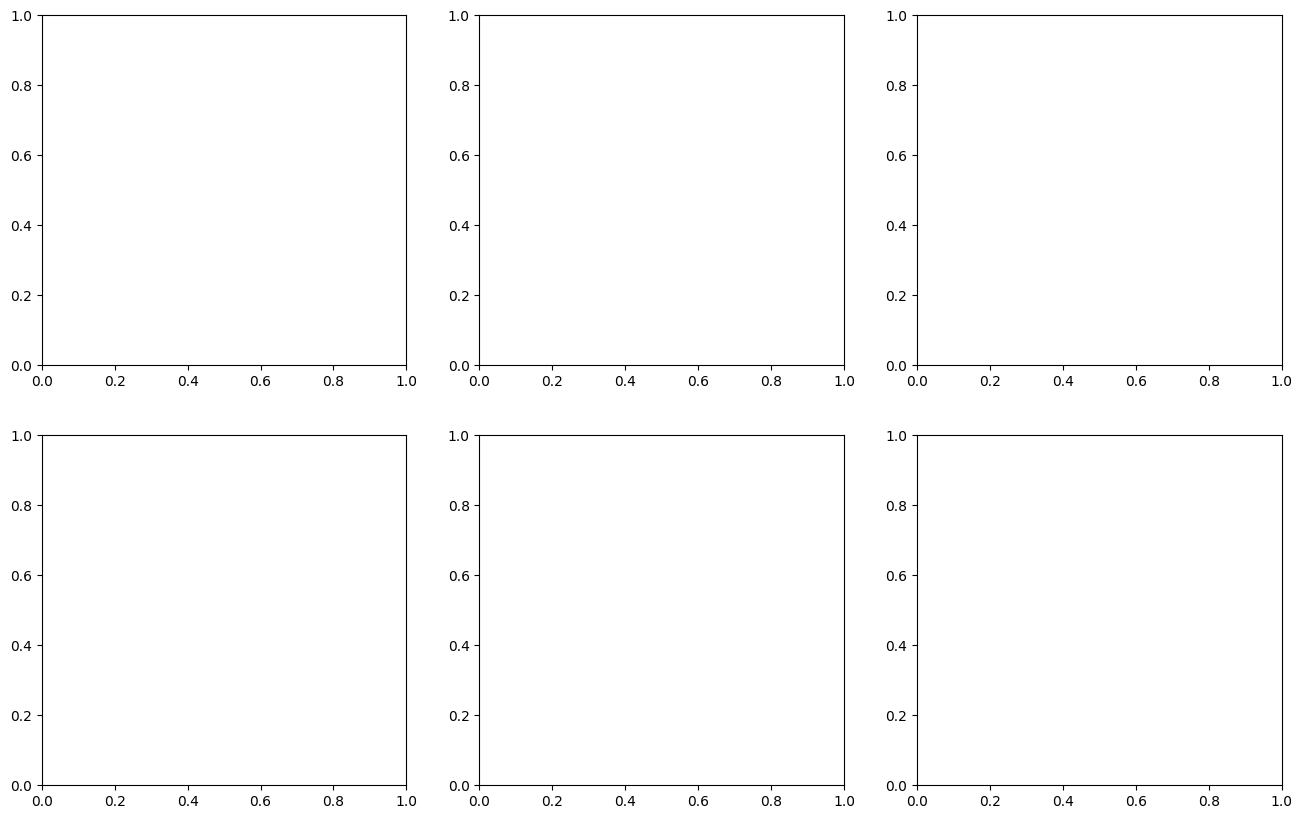

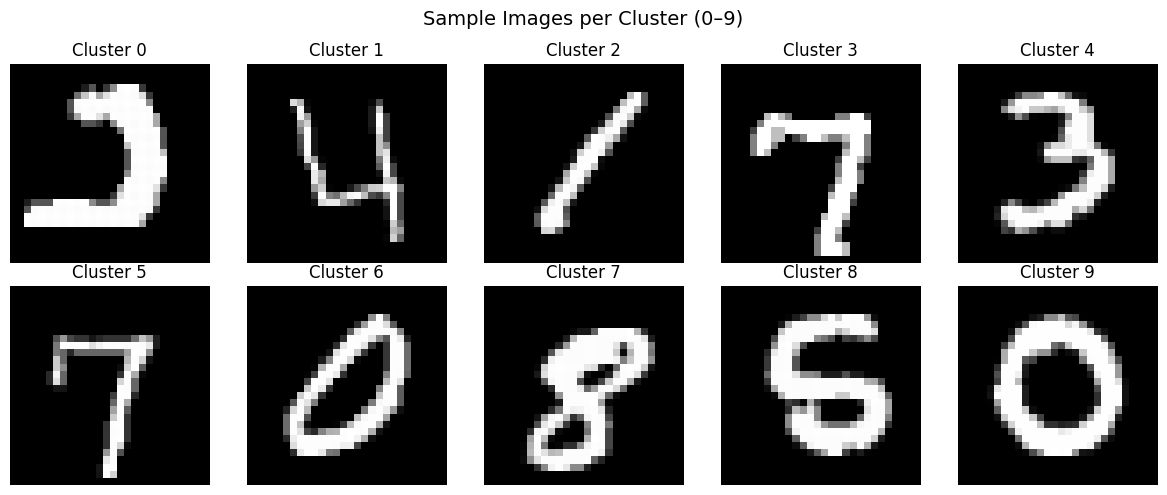

/var/folders/jm/pqwmz8414xd2zxjpxfmdkt_c0000gn/T/ipykernel_26016/389039973.py:55: UserWarning: Adding colorbar to a different Figure <Figure size 1600x1000 with 7 Axes> than <Figure size 640x480 with 0 Axes> which fig.colorbar is called on.
  plt.colorbar(sc, ax=axes[0, 2], label='Cluster')


<Figure size 640x480 with 0 Axes>

EDA complete!


In [2]:
def perform_eda(df, labels):
    """
    Complete EDA in one function:
    - Summary statistics
    - Sample digit images
    - Histogram of pixel intensities
    - Bar chart of class distribution
    - Scatter plot of two pixels
    - Correlation heatmap
    - Box plot of mean pixel per class
    """

    # --- Summary Statistics ---
    print("=== Summary Statistics (center pixels) ===")
    print(df[['pixel390', 'pixel391', 'pixel392']].describe())

    # Add labels temporarily for EDA
    df_eda = df.copy()
    df_eda['label'] = labels

    fig, axes = plt.subplots(2, 3, figsize=(16, 10))

    # 1. Sample Images (one per cluster/digit)
    fig2, ax2 = plt.subplots(2, 5, figsize=(12, 5))
    fig2.suptitle('Sample Images per Cluster (0–9)', fontsize=14)
    for digit in range(10):
        sample = df_eda[df_eda['label'] == digit].iloc[0, :-1].values.reshape(28, 28)
        ax2[digit // 5][digit % 5].imshow(sample, cmap='gray')
        ax2[digit // 5][digit % 5].set_title(f'Cluster {digit}')
        ax2[digit // 5][digit % 5].axis('off')
    plt.tight_layout()
    plt.show()

    # 2. Bar Chart: Cluster Distribution
    class_counts = df_eda['label'].value_counts().sort_index()
    axes[0, 0].bar(class_counts.index, class_counts.values, color='steelblue', edgecolor='black')
    axes[0, 0].set_title('Bar Chart: Cluster Distribution')
    axes[0, 0].set_xlabel('Cluster')
    axes[0, 0].set_ylabel('Count')

    # 3. Histogram: Pixel Intensity
    pixel_vals = df.values.flatten()
    axes[0, 1].hist(pixel_vals[pixel_vals > 0], bins=50, color='orange', edgecolor='black')
    axes[0, 1].set_title('Histogram: Non-Zero Pixel Intensities')
    axes[0, 1].set_xlabel('Pixel Value (0–255)')
    axes[0, 1].set_ylabel('Frequency')

    # 4. Scatter Plot: Two center pixels colored by cluster
    sample_idx = df_eda.sample(500, random_state=42)
    sc = axes[0, 2].scatter(sample_idx['pixel390'], sample_idx['pixel391'],
                             c=sample_idx['label'], cmap='tab10', alpha=0.6, s=15)
    axes[0, 2].set_title('Scatter Plot: pixel390 vs pixel391')
    axes[0, 2].set_xlabel('pixel390')
    axes[0, 2].set_ylabel('pixel391')
    plt.colorbar(sc, ax=axes[0, 2], label='Cluster')

    # 5. Heatmap: Correlation of 8 center pixels
    center = [f'pixel{i}' for i in range(384, 392)]
    sns.heatmap(df[center].corr(), ax=axes[1, 0], annot=True,
                fmt='.2f', cmap='coolwarm', linewidths=0.5)
    axes[1, 0].set_title('Heatmap: Correlation of Center Pixels')

    # 6. Box Plot: Mean pixel intensity per cluster
    df_eda['mean_pixel'] = df.mean(axis=1)
    df_eda.boxplot(column='mean_pixel', by='label', ax=axes[1, 1])
    axes[1, 1].set_title('Box Plot: Mean Pixel Intensity per Cluster')
    axes[1, 1].set_xlabel('Cluster')
    axes[1, 1].set_ylabel('Mean Pixel Intensity')
    plt.suptitle('')  # remove default title from boxplot

    # 7. Heatmap: Average image of cluster 0
    avg_img = df_eda[df_eda['label'] == 0].drop(columns=['label', 'mean_pixel']).mean().values.reshape(28, 28)
    sns.heatmap(avg_img, ax=axes[1, 2], cmap='gray', cbar=True)
    axes[1, 2].set_title('Heatmap: Average Image of Cluster 0')

    plt.tight_layout()
    plt.show()
    print("EDA complete!")


# Create initial labels using KMeans for EDA visualization
X_raw = df.values / 255.0
km_eda = MiniBatchKMeans(n_clusters=10, random_state=42, n_init=3)
initial_labels = km_eda.fit_predict(X_raw)

perform_eda(df, initial_labels)

## Step iii: Data Preprocessing

In [3]:
X = df.copy()

# 1. Handle missing values (fill with 0 = black pixel)
print("Missing values before fill:", X.isnull().sum().sum())
X.fillna(0, inplace=True)

# 2. Drop irrelevant features (columns that are always 0 = border pixels with no info)
constant_cols = [col for col in X.columns if X[col].nunique() == 1]
X.drop(columns=constant_cols, inplace=True)
print(f"Dropped {len(constant_cols)} constant columns (always zero = no information)")
print(f"Features remaining: {X.shape[1]}")

# 3. No categorical variables in MNIST (all columns are numeric pixel values)
print("All features are numeric — no label encoding needed")

# 4. Normalize: scale pixel values from [0, 255] to [0, 1]
X_norm = X / 255.0
print(f"\nBefore normalization — Min: {X.values.min()}, Max: {X.values.max()}")
print(f"After normalization  — Min: {X_norm.values.min():.1f}, Max: {X_norm.values.max():.1f}")

# 5. Assign labels using KMeans (10 clusters for 10 digit classes)
km = MiniBatchKMeans(n_clusters=10, random_state=42, n_init=5, max_iter=200)
y = km.fit_predict(X_norm)
print(f"\nLabels assigned via KMeans — Unique clusters: {np.unique(y)}")

Missing values before fill: 0


Dropped 76 constant columns (always zero = no information)
Features remaining: 708
All features are numeric — no label encoding needed

Before normalization — Min: 0, Max: 255
After normalization  — Min: 0.0, Max: 1.0



Labels assigned via KMeans — Unique clusters: [0 1 2 3 4 5 6 7 8 9]


## Step iv: Feature Selection

Chi-Square selected shape: (42000, 100)


ANOVA F-Test selected shape: (42000, 100)


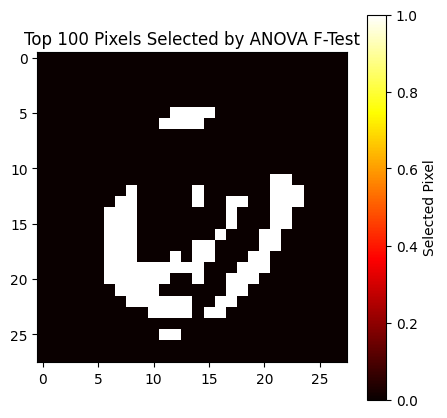


Using ANOVA-selected features for model training.


In [4]:
# Select top 100 most informative pixels from 708 remaining pixels

# Method 1: Chi-Square Test (requires non-negative values — satisfied since pixels in [0,1])
sel_chi2 = SelectKBest(chi2, k=100)
X_chi2 = sel_chi2.fit_transform(X_norm, y)
print("Chi-Square selected shape:", X_chi2.shape)

# Method 2: ANOVA F-Test (best for continuous features)
sel_anova = SelectKBest(f_classif, k=100)
X_anova = sel_anova.fit_transform(X_norm, y)
print("ANOVA F-Test selected shape:", X_anova.shape)

# Visualize which pixels were selected (shown on 28x28 grid)
selected_mask = sel_anova.get_support()  # True/False for each of 708 features

# Map selected features back to original 784 pixel positions
full_mask = np.zeros(784, dtype=bool)
original_indices = [int(col.replace('pixel', '')) for col in X.columns]
for i, orig_idx in enumerate(original_indices):
    if selected_mask[i]:
        full_mask[orig_idx] = True

plt.figure(figsize=(5, 5))
plt.imshow(full_mask.reshape(28, 28), cmap='hot')
plt.colorbar(label='Selected Pixel')
plt.title('Top 100 Pixels Selected by ANOVA F-Test')
plt.show()

# Use ANOVA-selected features for training
X_selected = X_anova
print("\nUsing ANOVA-selected features for model training.")

## Step v: Data Splitting (Train / Validation / Test)

Train set      : 29398 samples  (~70%)
Validation set : 6302 samples  (~15%)
Test set       : 6300 samples  (~15%)


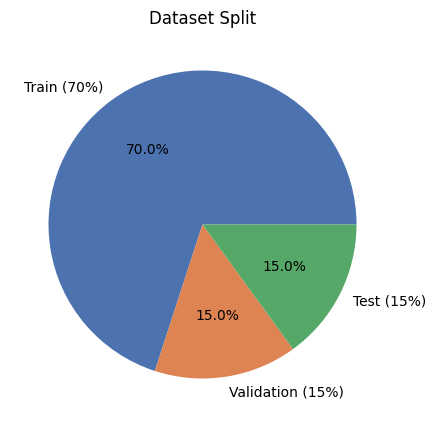

In [5]:
# Split into Train (70%) | Validation (15%) | Test (15%)

# First split: 85% train+val, 15% test
X_tv, X_test, y_tv, y_test = train_test_split(
    X_selected, y, test_size=0.15, random_state=42, stratify=y
)

# Second split: from 85%, take ~17.6% as validation → gives ~15% of total
X_train, X_val, y_train, y_val = train_test_split(
    X_tv, y_tv, test_size=0.1765, random_state=42, stratify=y_tv
)

print(f"Train set      : {X_train.shape[0]} samples  (~70%)")
print(f"Validation set : {X_val.shape[0]} samples  (~15%)")
print(f"Test set       : {X_test.shape[0]} samples  (~15%)")

# Pie chart of split
plt.figure(figsize=(5, 5))
plt.pie(
    [X_train.shape[0], X_val.shape[0], X_test.shape[0]],
    labels=['Train (70%)', 'Validation (15%)', 'Test (15%)'],
    autopct='%1.1f%%',
    colors=['#4C72B0', '#DD8452', '#55A868']
)
plt.title('Dataset Split')
plt.show()

## Step vi: Model Training & Performance Evaluation

In [6]:
# Train Random Forest Classifier
model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

# Predictions on validation and test sets
y_val_pred  = model.predict(X_val)
y_test_pred = model.predict(X_test)

# Accuracy
print(f"Validation Accuracy : {accuracy_score(y_val,  y_val_pred):.4f}")
print(f"Test Accuracy       : {accuracy_score(y_test, y_test_pred):.4f}")

# Full Classification Report (Precision, Recall, F1-Score per class)
print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_test_pred))

Validation Accuracy : 0.8570
Test Accuracy       : 0.8594

Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.84      0.92      0.88       931
           1       0.81      0.73      0.77       513
           2       0.84      0.87      0.85       555
           3       0.89      0.84      0.86       598
           4       0.86      0.86      0.86       749
           5       0.89      0.90      0.89       703
           6       0.78      0.83      0.81       709
           7       0.95      0.93      0.94       501
           8       0.89      0.78      0.83       584
           9       0.89      0.90      0.89       457

    accuracy                           0.86      6300
   macro avg       0.86      0.86      0.86      6300
weighted avg       0.86      0.86      0.86      6300



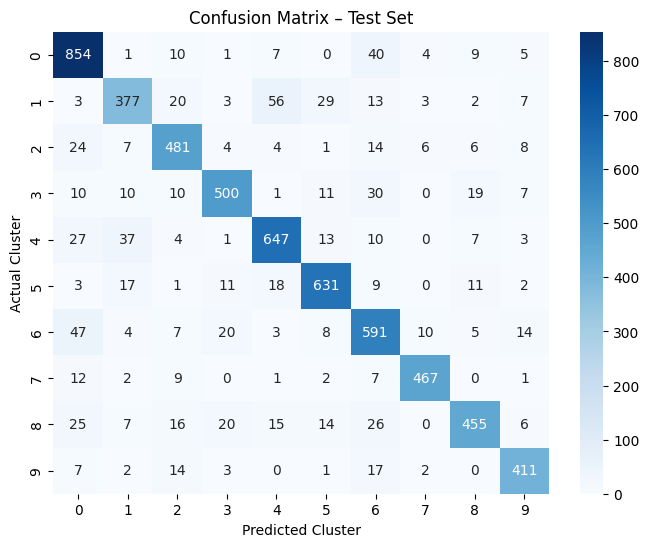

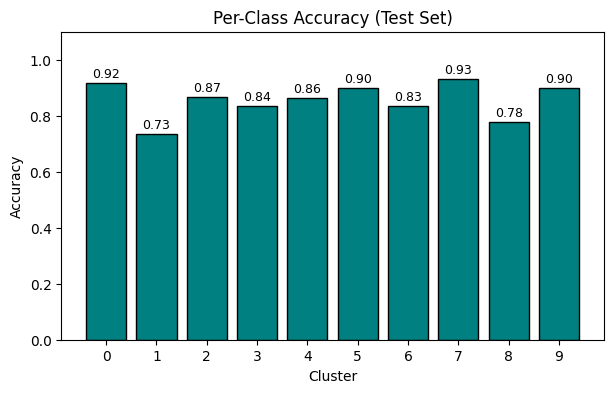


========== Summary ==========
  Task Type     : Multi-class Classification (Supervised Learning)
  Labels        : Assigned via KMeans Clustering (10 clusters)
  Model         : Random Forest (100 Decision Trees)
  Features Used : Top 100 pixels via ANOVA F-Test
  Test Accuracy : 0.8594
  Metrics Used  : Accuracy, Precision, Recall, F1-Score, Confusion Matrix


In [7]:
# --- Confusion Matrix Heatmap ---
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10), yticklabels=range(10))
plt.title('Confusion Matrix – Test Set')
plt.xlabel('Predicted Cluster')
plt.ylabel('Actual Cluster')
plt.show()

# --- Per-Class Accuracy Bar Chart ---
per_class_acc = cm.diagonal() / cm.sum(axis=1)

plt.figure(figsize=(7, 4))
bars = plt.bar(range(10), per_class_acc, color='teal', edgecolor='black')
plt.xticks(range(10))
plt.ylim(0, 1.1)
plt.title('Per-Class Accuracy (Test Set)')
plt.xlabel('Cluster')
plt.ylabel('Accuracy')
for i, v in enumerate(per_class_acc):
    plt.text(i, v + 0.02, f'{v:.2f}', ha='center', fontsize=9)
plt.show()

# --- Summary ---
print("\n========== Summary ==========")
print("  Task Type     : Multi-class Classification (Supervised Learning)")
print("  Labels        : Assigned via KMeans Clustering (10 clusters)")
print("  Model         : Random Forest (100 Decision Trees)")
print("  Features Used : Top 100 pixels via ANOVA F-Test")
print(f"  Test Accuracy : {accuracy_score(y_test, y_test_pred):.4f}")
print("  Metrics Used  : Accuracy, Precision, Recall, F1-Score, Confusion Matrix")